**Author: Atanazy Gawrysiak**

#Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

#Loading Data

In [ ]:
df_raw = pd.read_csv('zad2_wum_data_for_students.csv', sep =";")
X = df_raw.iloc[:,2:]
y_class = df_raw["Class"]
y_output = df_raw["Output"]
X_train, X_test, y_class_train, y_class_test, y_output_train, y_output_test = train_test_split(X, y_class, y_output, test_size=0.2, random_state=42)
y_class.value_counts()

,count
Class,
1,1013
0,987


Fortunately classes are balanced.

#Baseline models

##Linear Regression

In [ ]:
baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_output_train)
y_output_pred_train = baseline_lr.predict(X_train)
y_output_pred_test = baseline_lr.predict(X_test)
mse_train = mean_squared_error(y_output_train, y_output_pred_train)
mse_test = mean_squared_error(y_output_test, y_output_pred_test)
r2_train = r2_score(y_output_train, y_output_pred_train)
r2_test = r2_score(y_output_test, y_output_pred_test)
lr_cv_scores = -cross_val_score(baseline_lr, X, y_output, scoring='neg_mean_squared_error', cv=5)
r2_scores = cross_val_score(baseline_lr, X, y_output, scoring='r2', cv=5)
print("MSE train: ", mse_train)
print("MSE test: ", mse_test)
print("R2 train: ", r2_train)
print("R2 test: ", r2_test)
print("Cross validation:")
print("Mean MSE score: ", lr_cv_scores.mean())
print("Mean R2 score: ", r2_scores.mean())

MSE train:  4.8792275717147815
MSE test:  7.00823743492357
R2 train:  0.6154592756878907
R2 test:  0.446399074688859
Cross validation:
Mean MSE score:  8.30238600024177
Mean R2 score:  0.34228035764705034


Model performs significantly better on the training set than on the test set.
This gap indicates overfitting - the model is capturing patterns and noise from the training data that don't generalize well. The cross-validation MSE is even higher than the test MSE, which further confirms the limited generalization ability of the model.

## Logistic Regression

In [ ]:
baseline_logr = LogisticRegression(max_iter=1000)
baseline_logr.fit(X_train, y_class_train)
y_class_pred_train = baseline_logr.predict(X_train)
y_class_pred_test = baseline_logr.predict(X_test)
acc_train = accuracy_score(y_class_train, y_class_pred_train)
acc_test = accuracy_score(y_class_test, y_class_pred_test)
logr_cv_scores = cross_val_score(baseline_logr, X, y_class, scoring='accuracy', cv=5)
print("Accuracy train: ", acc_train)
print("Accuracy test: ", acc_test)
print("Mean CV score: ", logr_cv_scores.mean())

Accuracy train:  0.73875
Accuracy test:  0.5175
Mean CV score:  0.542


The train accuracy is much higher than both the test and CV accuracy, which again indicates overfitting. Test and CV accuracy are near random (~50%). This suggests that the model is struggling to learn anything at all.

#Advanced Classification

## PCA + SVM

Firstly, I improved the baseline model using a pipeline with SelectKBest, PCA, and an SVM classifier. Hyperparameters were optimized using GridSearchCV with 5-fold cross-validation. The dataset has 2000 samples and 400 input features, which makes it a high-dimensional setting. Many of these features are likely irrelevant or redundant, which is why I used SelectKBest to retain the most informative ones. PCA was then applied to reduce redundancy and compress correlated features before classification.


In [ ]:
pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('pca', PCA()),
    ('svm', SVC(random_state=42))
])

param_grid = {
    'select__k': [10, 20, 30],
    'pca__n_components': [5, 10],
    'svm__C': [0.1, 1, 10, 20],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_class_train)

print("Best parameters:", grid_search.best_params_)

best_class_model_pcasvm = grid_search.best_estimator_
selected_mask = best_class_model_pcasvm.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
print("Selected features:", selected_feature_names.tolist())


y_train_pred = best_class_model_pcasvm.predict(X_train)
y_test_pred = best_class_model_pcasvm.predict(X_test)

print("Train accuracy:", accuracy_score(y_class_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_class_test, y_test_pred))


Best parameters: {'pca__n_components': 10, 'select__k': 10, 'svm__C': 20, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Selected features: ['Input2', 'Input40', 'Input41', 'Input74', 'Input238', 'Input240', 'Input293', 'Input308', 'Input330', 'Input396']
Train accuracy: 0.844375
Test accuracy: 0.815


As we can see, the model achived decent accuracy.

## KBest + Logistic Regression

I trained a baseline model using Logistic Regression with SelectKBest for feature selection. The best number of features (k=10) was selected using GridSearchCV with 5-fold cross-validation.

In [ ]:
pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'select__k': list(range(10, 101, 5))
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_class_train)

best_class_model_kblr = grid_search.best_estimator_

y_pred_train = best_class_model_kblr.predict(X_train)
train_acc = accuracy_score(y_class_train, y_pred_train)
y_pred_test = best_class_model_kblr.predict(X_test)
test_acc = accuracy_score(y_class_test, y_pred_test)

print("Best number of features (k):", grid_search.best_params_['select__k'])

selected_mask = best_class_model_kblr.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
print("Selected features:", selected_feature_names.tolist())

print("Test accuracy:", test_acc)
print("Train accuracy:", train_acc)

Best number of features (k): 10
Selected features: ['Input2', 'Input40', 'Input41', 'Input74', 'Input238', 'Input240', 'Input293', 'Input308', 'Input330', 'Input396']
Test accuracy: 0.5675
Train accuracy: 0.55875


This shows that the linear regression struggles to capture complex patterns in the data, likely due to the non-linear dependencies that this model cannot handle.

##KBest + MLP

I also experimented with model using SelectKBest for feature selection and a Multilayer Perceptron (MLP) for classification. Hyperparameters were tuned using GridSearchCV with 5-fold cross-validation.

In [ ]:
pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('mlp', MLPClassifier(max_iter=1000, early_stopping=True ,random_state=42))
])

param_grid = {
    'select__k': [5, 10, 20, 50],
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (50, 50, 50), (100, 100, 100),],
    'mlp__alpha': [0.001, 0.01, 1, 10],
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_class_train)
best_class_model_mlp = grid.best_estimator_

print("Best params:", grid.best_params_)

selected_mask = best_class_model_mlp.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
print("Selected features:", selected_feature_names.tolist())

y_pred_test = best_class_model_mlp.predict(X_test)
y_pred_train = best_class_model_mlp.predict(X_train)
print("Train accuracy:", accuracy_score(y_class_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_class_test, y_pred_test))

Best params: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (100, 100, 100), 'select__k': 10}
Selected features: ['Input2', 'Input40', 'Input41', 'Input74', 'Input238', 'Input240', 'Input293', 'Input308', 'Input330', 'Input396']
Train accuracy: 0.850625
Test accuracy: 0.8325


The use of a deep neural network with three hidden layers allows it to capture complex, non-linear dependencies in the data. Feature selection helps reduce overfitting by focusing on the most relevant inputs. This gives the best results so far.

##KBest + RandomForest

I used a pipeline combining SelectKBest for feature selection and a Random Forest classifier. Hyperparameters were tuned using GridSearchCV with 5-fold cross-validation.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'select__k': [10, 30, 50],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_class_train)

best_class_model_kbrf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

selected_mask = best_class_model_kbrf.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
print("Selected features:", selected_feature_names.tolist())

y_test_pred = best_class_model_kbrf.predict(X_test)
y_train_pred = best_class_model_kbrf.predict(X_train)

print("Train accuracy:", accuracy_score(y_class_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_class_test, y_test_pred))

Best parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__n_estimators': 200, 'select__k': 10}
Selected features: ['Input2', 'Input40', 'Input41', 'Input74', 'Input238', 'Input240', 'Input293', 'Input308', 'Input330', 'Input396']
Train accuracy: 1.0
Test accuracy: 0.83


##Summary

Almost all of the models above consistently identified the following as the most important features for classification: 'Input2', 'Input40', 'Input41', 'Input74', 'Input238', 'Input240', 'Input293', 'Input308', 'Input330', and 'Input396'. The MLP and Random Forest models achieved the best test accuracy. While Random Forest slightly overfits, MLP offers a strong balance between complexity and generalization.

#Advanced Regression

##KBest + Random Forest

Random Forest worked well for classification, so I also tried it for regression. I applied pipeline with SelectKBest (using f_regression) and a Random Forest Regressor to predict the continuous output variable. Hyperparameters were tuned via GridSearchCV with 5-fold cross-validation, optimizing the R2 score.

In [ ]:
pipe = Pipeline([
    ('select', SelectKBest(score_func=f_regression)),
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid = {
    'select__k': [5, 10, 30, 50],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_output_train)

best_reg_model_kbrf = grid.best_estimator_
print("Best params:", grid.best_params_)

selected_mask = best_reg_model_kbrf.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
print("Selected features:", selected_feature_names.tolist())

y_pred_train = best_reg_model_kbrf.predict(X_train)
y_pred_test = best_reg_model_kbrf.predict(X_test)

r2_train = r2_score(y_output_train, y_pred_train)
r2_test = r2_score(y_output_test, y_pred_test)
mse_train = mean_squared_error(y_output_train, y_pred_train)
mse_test = mean_squared_error(y_output_test, y_pred_test)

print("Train R2:", r2_train)
print("Train MSE:", mse_train)
print("Test R2:", r2_test)
print("Test MSE:", mse_test)

Best params: {'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__n_estimators': 200, 'select__k': 30}
Selected features: ['Input13', 'Input18', 'Input57', 'Input83', 'Input136', 'Input143', 'Input153', 'Input167', 'Input173', 'Input179', 'Input184', 'Input193', 'Input204', 'Input223', 'Input241', 'Input250', 'Input258', 'Input286', 'Input292', 'Input294', 'Input295', 'Input298', 'Input301', 'Input342', 'Input359', 'Input376', 'Input377', 'Input385', 'Input388', 'Input389']
Train R2: 0.9091646201366422
Train MSE: 1.1525606051460913
Test R2: 0.37589143492678323
Test MSE: 7.900819542063232


The model fits the training data very well, but the significant drop in test performance suggests overfitting or indicates that the output variable is inherently more difficult to predict than the class variable. The list of selected features is shown above.

##Lasso

I applied LassoCV directly to the dataset to perform both feature selection and hyperparameter tuning. Lasso inherently shrinks some coefficients to zero, effectively identifying the most relevant predictors. Additionally, LassoCV automatically searches for the optimal regularization parameter (alpha) using cross-validation.

      feature      coef
222  Input223  0.854805
82    Input83  0.834062
166  Input167  0.710598
291  Input292  0.684242
192  Input193  0.605653
341  Input342  0.603793
183  Input184  0.561307
135  Input136  0.506334
172  Input173  0.459226
386  Input387  0.371464
17    Input18  0.321754
388  Input389  0.278033
240  Input241  0.265268
58    Input59  0.232192
284  Input285 -0.058871
303  Input304  0.042849
24    Input25  0.041768
285  Input286  0.034860
230  Input231 -0.034734
249  Input250  0.030285
269  Input270 -0.029185
212  Input213  0.024259
280  Input281 -0.023628
66    Input67 -0.023348
297  Input298 -0.021797
171  Input172 -0.018598
193  Input194  0.017295
40    Input41  0.016551
299  Input300 -0.015885
155  Input156  0.012751
387  Input388  0.012354
203  Input204 -0.011567
323  Input324 -0.010546
131  Input132  0.009926
67    Input68 -0.009641
122  Input123 -0.009543
93    Input94  0.007673
334  Input335  0.007415
130  Input131 -0.006069
97    Input98  0.003985
99   Input100 -0

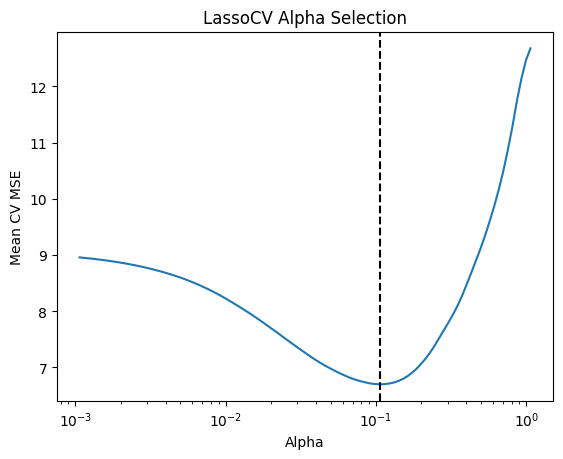

Best alpha: 0.10665493823091028


In [ ]:
lasso_model = LassoCV(cv=5, random_state=42)
lasso_model.fit(X_train, y_output_train)

y_pred_train = lasso_model.predict(X_train)
y_pred_test = lasso_model.predict(X_test)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lasso_model.coef_
})
print(coef_df[coef_df['coef'] != 0].sort_values(by='coef', key=abs, ascending=False))

print("Train R2:", r2_score(y_output_train, y_pred_train))
print("Train MSE:", mean_squared_error(y_output_train, y_pred_train))
print("Test R2:", r2_score(y_output_test, y_pred_test))
print("Test MSE:", mean_squared_error(y_output_test, y_pred_test))


plt.semilogx(lasso_model.alphas_, np.mean(lasso_model.mse_path_, axis=1))
plt.axvline(lasso_model.alpha_, linestyle='--', color='k')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV Alpha Selection")
plt.show()
print("Best alpha:", lasso_model.alpha_)

The most influential predictors include Input223, Input83, Input167, and Input292, among others. The optimal regularization parameter (alpha) was automatically selected through cross-validation, with the best value found to be approximately 0.107.The model achieved a training R2 of approximately 0.51 and a test R2 of about 0.53, with corresponding MSE values around 6.19 (train) and 5.89 (test). This indicates moderate predictive performance and reasonable generalization to unseen data.

##KBest + MLP

I applied a pipeline combining SelectKBest for feature selection and an MLPRegressor to capture complex, nonlinear relationships. Hyperparameters—including the number of selected features, hidden layer sizes, and regularization strength—were optimized with GridSearchCV using 5-fold cross-validation.

In [ ]:
pipe = Pipeline([
    ('select', SelectKBest(score_func=f_regression)),
    ('mlp', MLPRegressor(max_iter=1000, early_stopping=True, random_state=42))
])

param_grid = {
    'select__k': [5, 10, 20, 50],
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (50, 50, 50), (100, 100, 100),],
    'mlp__alpha': [0.001, 0.01, 1, 10],
}

grid = GridSearchCV(pipe, param_grid, scoring='r2', cv=5, n_jobs=-1)
grid.fit(X_train, y_output_train)

best_reg_model_mlp = grid.best_estimator_

selected_mask = best_reg_model_mlp.named_steps['select'].get_support()
selected_feature_names = X_train.columns[selected_mask]
y_pred_train = best_reg_model_mlp.predict(X_train)
y_pred_test = best_reg_model_mlp.predict(X_test)

r2_train = r2_score(y_output_train, y_pred_train)
r2_test = r2_score(y_output_test, y_pred_test)
mse_train = mean_squared_error(y_output_train, y_pred_train)
mse_test = mean_squared_error(y_output_test, y_pred_test)

print("Best params:", grid.best_params_)
print("Selected features:", selected_feature_names.tolist())
print("Train R2:", r2_train)
print("Train MSE:", mse_train)
print("Test R2:", r2_test)
print("Test MSE:", mse_test)

Best params: {'mlp__alpha': 10, 'mlp__hidden_layer_sizes': (100,), 'select__k': 20}
Selected features: ['Input18', 'Input83', 'Input136', 'Input167', 'Input173', 'Input184', 'Input193', 'Input204', 'Input223', 'Input241', 'Input250', 'Input286', 'Input292', 'Input294', 'Input298', 'Input301', 'Input376', 'Input385', 'Input388', 'Input389']
Train R2: 0.4528398564677336
Train MSE: 6.9426167104714684
Test R2: 0.47326384675791133
Test MSE: 6.668146418657285


The model selected 20 important features listed above. Performance on the training set was moderate with R2 = 0.45 and MSE = 6.94, while the test set showed similar generalization with R2 = 0.47 and MSE = 6.67. This indicates a reasonable fit with consistent performance on unseen data, slightly improving over simpler baseline models.

#Processing Validation Data

Function to test models on other datasets. By deafult it uses MLP model for classification and lasso for regression, but it can be changed.

In [ ]:
def evaluate_on_validation_set(classification_model=best_class_model_mlp, regression_model=lasso_model, file_name="validation_data.csv"):
    df_raw = pd.read_csv(file_name, sep =";")
    X = df_raw.iloc[:,2:]
    y_class = df_raw["Class"]
    y_output = df_raw["Output"]
    y_class_pred_baseline = baseline_logr.predict(X)
    y_output_pred_baseline = baseline_lr.predict(X)
    y_class_pred = classification_model.predict(X)
    y_output_pred = regression_model.predict(X)
    print("Baseline classification accuracy :", accuracy_score(y_class, y_class_pred_baseline))
    print("Baseline regression R2:", r2_score(y_output, y_output_pred_baseline))
    print("Best model's classification accuracy :", accuracy_score(y_class, y_class_pred))
    print("Best model's regression R2:", r2_score(y_output, y_output_pred))

Example usage:

In [ ]:
evaluate_on_validation_set()

FileNotFoundError: [Errno 2] No such file or directory: 'validation_data.csv'

In [ ]:
evaluate_on_validation_set(classification_model=best_class_model_pcasvm, regression_model=best_reg_model_mlp)

FileNotFoundError: [Errno 2] No such file or directory: 'validation_data.csv'

In [ ]:
evaluate_on_validation_set(classification_model=best_class_model_kbrf)

FileNotFoundError: [Errno 2] No such file or directory: 'validation_data.csv'